# Assignment 12: Simulating Data Parallelism and ZeRO with 32 Virtual GPUs

This notebook creates **32 simultaneous CPU worker threads** as virtual GPU ranks and trains a small linear model for multiple Adam steps. It compares ordinary data parallelism with ZeRO stages 1, 2, and 3.

The experiment demonstrates four ideas:

1. Sharding changes state ownership, memory, optimizer work, and communication.
2. It does not change the mathematical update when the collectives are correct.
3. ZeRO-1 and ZeRO-2 retain roughly the communication volume of data parallelism while reducing persistent state.
4. ZeRO-3 minimizes persistent state but must materialize parameter shards for computation.

The simulator uses a central controller to emulate collectives, while each virtual rank owns real NumPy arrays and performs its model/optimizer work on a worker thread. It is a conceptual distributed-training simulator, not a GPU speed benchmark.

## 1. Session 12 accounting assumptions

For each parameter, training stores:

| State | Format | Bytes |
|---|---:|---:|
| Compute parameter | FP16 | 2 |
| Gradient | FP16 | 2 |
| Master parameter | FP32 | 4 |
| Adam first moment | FP32 | 4 |
| Adam second moment | FP32 | 4 |
| **Total before sharding** |  | **16** |

With world size `N`, persistent bytes per parameter per rank are:

- Data parallel: `16`
- ZeRO-1: `4 + 12/N`
- ZeRO-2: `2 + 14/N`
- ZeRO-3: `16/N`

`P` denotes one complete FP16 parameter copy. A ring all-reduce costs `2(N-1)/N × P` per rank. A reduce-scatter or all-gather costs `(N-1)/N × P`. Session 12 rounds these to `2P`, `P`, and `P`.

In [1]:
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass
import threading
import time
import numpy as np

WORLD_SIZE = 32
PARAM_COUNT = 1024
SAMPLES_PER_RANK = 8
TRAIN_STEPS = 4
LEARNING_RATE = 5e-3
SEED = 12

assert PARAM_COUNT % WORLD_SIZE == 0
SHARD_SIZE = PARAM_COUNT // WORLD_SIZE
SLICES = [slice(rank * SHARD_SIZE, (rank + 1) * SHARD_SIZE) for rank in range(WORLD_SIZE)]
np.set_printoptions(precision=6, suppress=True)

print(f"World size: {WORLD_SIZE} virtual ranks")
print(f"Toy model size: {PARAM_COUNT:,} parameters ({SHARD_SIZE} per shard)")
print(f"Global batch per step: {WORLD_SIZE * SAMPLES_PER_RANK} samples")
print(f"Training steps: {TRAIN_STEPS}")

World size: 32 virtual ranks
Toy model size: 1,024 parameters (32 per shard)
Global batch per step: 256 samples
Training steps: 4


## 2. Demo model and data

The model is linear regression: `prediction = X @ w`. Each rank receives a different microbatch. All strategies start from identical parameters and consume exactly the same batches in the same order.

In [2]:
rng = np.random.default_rng(SEED)
true_w = rng.normal(0, 0.25, size=PARAM_COUNT).astype(np.float32)
initial_master = rng.normal(0, 0.02, size=PARAM_COUNT).astype(np.float32)


def make_batches(generator):
    batches = []
    for _ in range(WORLD_SIZE):
        x = generator.normal(size=(SAMPLES_PER_RANK, PARAM_COUNT)).astype(np.float32)
        noise = generator.normal(0, 0.01, size=SAMPLES_PER_RANK).astype(np.float32)
        y = x @ true_w + noise
        batches.append((x, y))
    return batches


training_batches = [make_batches(rng) for _ in range(TRAIN_STEPS)]
evaluation_batches = make_batches(rng)


def mse_loss(weights_fp16, batches):
    w = weights_fp16.astype(np.float32)
    squared_error = 0.0
    examples = 0
    for x, y in batches:
        error = x @ w - y
        squared_error += float(error @ error)
        examples += len(y)
    return squared_error / examples


print(f"Initial evaluation loss: {mse_loss(initial_master.astype(np.float16), evaluation_batches):.6f}")

Initial evaluation loss: 65.242112


## 3. Per-rank persistent state

Each virtual rank owns actual arrays matching its stage. The reported toy memory below is measured from `array.nbytes`; it is not inferred only from a formula.

- Data parallel owns complete parameters, gradients, FP32 master parameters, and Adam states.
- ZeRO-1 owns complete parameters and gradients, but only one optimizer shard.
- ZeRO-2 owns complete parameters and one gradient/optimizer shard.
- ZeRO-3 owns one shard of every persistent state.

Temporary full gradients and ZeRO-3 parameter gathers are controller buffers and are reported separately from persistent rank state.

In [3]:
@dataclass
class RankState:
    rank: int
    parameters: np.ndarray
    gradients: np.ndarray
    master: np.ndarray
    adam_m: np.ndarray
    adam_v: np.ndarray

    def component_bytes(self):
        return {
            "parameters": self.parameters.nbytes,
            "gradients": self.gradients.nbytes,
            "optimizer": self.master.nbytes + self.adam_m.nbytes + self.adam_v.nbytes,
        }

    def persistent_bytes(self):
        return sum(self.component_bytes().values())


def create_states(strategy):
    states = []
    for rank, owned in enumerate(SLICES):
        if strategy == "Data Parallel":
            parameters = initial_master.astype(np.float16).copy()
            gradients = np.zeros(PARAM_COUNT, dtype=np.float16)
            master = initial_master.copy()
        elif strategy == "ZeRO-1":
            parameters = initial_master.astype(np.float16).copy()
            gradients = np.zeros(PARAM_COUNT, dtype=np.float16)
            master = initial_master[owned].copy()
        elif strategy == "ZeRO-2":
            parameters = initial_master.astype(np.float16).copy()
            gradients = np.zeros(SHARD_SIZE, dtype=np.float16)
            master = initial_master[owned].copy()
        elif strategy == "ZeRO-3":
            parameters = initial_master[owned].astype(np.float16).copy()
            gradients = np.zeros(SHARD_SIZE, dtype=np.float16)
            master = initial_master[owned].copy()
        else:
            raise ValueError(strategy)
        states.append(
            RankState(
                rank=rank,
                parameters=parameters,
                gradients=gradients,
                master=master,
                adam_m=np.zeros_like(master),
                adam_v=np.zeros_like(master),
            )
        )
    return states


STRATEGIES = ["Data Parallel", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
initial_states = {strategy: create_states(strategy) for strategy in STRATEGIES}

print(f"{'Strategy':<15} {'Param bytes':>13} {'Grad bytes':>12} {'Optimizer bytes':>16} {'Total/rank':>13}")
print('-' * 73)
for strategy in STRATEGIES:
    parts = initial_states[strategy][0].component_bytes()
    print(
        f"{strategy:<15} {parts['parameters']:>13,} {parts['gradients']:>12,} "
        f"{parts['optimizer']:>16,} {sum(parts.values()):>13,}"
    )

Strategy          Param bytes   Grad bytes  Optimizer bytes    Total/rank
-------------------------------------------------------------------------
Data Parallel           2,048        2,048           12,288        16,384
ZeRO-1                  2,048        2,048              384         4,480
ZeRO-2                  2,048           64              384         2,496
ZeRO-3                     64           64              384           512


### Example shard ownership

The 1,024 model parameters are divided evenly across 32 ranks, so every shard contains 32 consecutive parameters. The stop index is exclusive, matching normal Python slicing. ZeRO-1 and ZeRO-2 use these ranges for optimizer ownership; ZeRO-3 uses the same ranges for parameters, gradients, and optimizer state.

In [4]:
example_ranks = [0, 1, 15, 30, 31]
print(f"{'Rank':>4} {'Python slice':>15} {'First index':>13} {'Last index':>12} {'Parameters':>12}")
print('-' * 63)
for rank in example_ranks:
    owned = SLICES[rank]
    print(
        f"{rank:>4} {f'[{owned.start}:{owned.stop})':>15} "
        f"{owned.start:>13} {owned.stop - 1:>12} {owned.stop - owned.start:>12}"
    )

covered = np.concatenate([np.arange(owned.start, owned.stop) for owned in SLICES])
np.testing.assert_array_equal(covered, np.arange(PARAM_COUNT))
print()
print("PASS: the 32 shards cover every parameter exactly once with no gaps or overlap.")

Rank    Python slice   First index   Last index   Parameters
---------------------------------------------------------------
   0          [0:32)             0           31           32
   1         [32:64)            32           63           32
  15       [480:512)           480          511           32
  30       [960:992)           960          991           32
  31      [992:1024)           992         1023           32

PASS: the 32 shards cover every parameter exactly once with no gaps or overlap.


## 4. Worker execution and collective accounting

Forward and backward are separated so ZeRO-3 can explicitly:

1. all-gather parameter shards for the forward pass;
2. release the gathered buffer;
3. all-gather again for the backward pass;
4. release it again;
5. reduce-scatter gradients and update only owned shards.

The controller records the exact ring-collective byte estimate per rank. At 32 ranks, `(N-1)/N = 31/32`, so the exact result is slightly below the rounded `P`, `2P`, or `3P` used in the lesson.

In [5]:
def all_gather(shards):
    return np.concatenate(shards)


def reduce_scatter_mean(full_gradients):
    averaged = np.mean(np.stack(full_gradients, axis=0), axis=0, dtype=np.float32)
    return [averaged[owned].copy() for owned in SLICES]


def all_reduce_mean(full_gradients):
    return np.mean(np.stack(full_gradients, axis=0), axis=0, dtype=np.float32)


def ring_all_gather_bytes(full_payload_bytes):
    return (WORLD_SIZE - 1) / WORLD_SIZE * full_payload_bytes


def ring_reduce_scatter_bytes(full_payload_bytes):
    return (WORLD_SIZE - 1) / WORLD_SIZE * full_payload_bytes


def ring_all_reduce_bytes(full_payload_bytes):
    return 2 * (WORLD_SIZE - 1) / WORLD_SIZE * full_payload_bytes


def parallel_map_32(function, items):
    barrier = threading.Barrier(WORLD_SIZE)

    def wrapped(item):
        barrier.wait()
        value = function(item)
        return threading.get_ident(), value

    with ThreadPoolExecutor(max_workers=WORLD_SIZE, thread_name_prefix="virtual-gpu") as pool:
        results = list(pool.map(wrapped, items))
    thread_count = len({thread_id for thread_id, _ in results})
    assert thread_count == WORLD_SIZE
    return [value for _, value in results], thread_count


def forward_worker(item):
    weights_fp16, batch = item
    x, y = batch
    return x @ weights_fp16.astype(np.float32) - y


def backward_worker(item):
    weights_fp16, error, batch = item
    x, y = batch
    assert weights_fp16.size == x.shape[1]
    # This is the gradient propagated into an earlier layer. Computing it
    # makes the ZeRO-3 backward parameter gather a real data dependency.
    input_gradient = (2.0 / len(y)) * error[:, None] * weights_fp16.astype(np.float32)[None, :]
    assert input_gradient.shape == x.shape
    parameter_gradient = (2.0 / len(y)) * (x.T @ error)
    return parameter_gradient.astype(np.float16)


def adam_update(master, m, v, gradient, step, lr=LEARNING_RATE,
                beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1.0 - beta1) * gradient
    v = beta2 * v + (1.0 - beta2) * (gradient * gradient)
    m_hat = m / (1.0 - beta1 ** step)
    v_hat = v / (1.0 - beta2 ** step)
    master = master - lr * m_hat / (np.sqrt(v_hat) + eps)
    return master.astype(np.float32), m.astype(np.float32), v.astype(np.float32)


def update_worker(item):
    state, gradient, step = item
    return adam_update(state.master, state.adam_m, state.adam_v, gradient, step)


print("Collectives and 32-worker execution helpers are ready.")

Collectives and 32-worker execution helpers are ready.


## 5. Multi-step simulation

The optimizer state is carried across four steps. This is stronger than a one-step check because Adam's moments must remain equivalent after repeated sharded updates.

For ZeRO-1 and ZeRO-2, the communication pattern is modeled as gradient reduce-scatter followed by updated-parameter all-gather. ZeRO-1 still reserves a full persistent gradient buffer per rank; ZeRO-2 retains only the owned shard. For ZeRO-3, the persistent parameter shards are gathered twice per step for forward and backward.

In [6]:
@dataclass
class RunResult:
    strategy: str
    states: list
    full_master: np.ndarray
    full_m: np.ndarray
    full_v: np.ndarray
    full_parameters_fp16: np.ndarray
    loss_after: float
    communication_bytes_per_rank: float
    communication_events: dict
    persistent_bytes_per_rank: int
    transient_peak_parameter_bytes: int
    transient_peak_gradient_bytes: int
    elapsed_seconds: float
    worker_threads: int


def reconstruct(states, field):
    first = getattr(states[0], field)
    if first.size == PARAM_COUNT:
        return first.copy()
    return np.concatenate([getattr(state, field) for state in states])


def run_strategy(strategy):
    states = create_states(strategy)
    param_payload = PARAM_COUNT * np.dtype(np.float16).itemsize
    communication = {"all_reduce": 0.0, "reduce_scatter": 0.0, "parameter_all_gather": 0.0}
    transient_peak = 0
    worker_threads = 0
    started = time.perf_counter()

    for step_index, batches in enumerate(training_batches, start=1):
        if strategy == "ZeRO-3":
            forward_weights = all_gather([state.parameters for state in states])
            communication["parameter_all_gather"] += ring_all_gather_bytes(param_payload)
            transient_peak = max(transient_peak, forward_weights.nbytes)
            forward_inputs = [(forward_weights, batch) for batch in batches]
        else:
            forward_inputs = [(states[rank].parameters, batches[rank]) for rank in range(WORLD_SIZE)]

        errors, threads = parallel_map_32(forward_worker, forward_inputs)
        worker_threads = max(worker_threads, threads)
        if strategy == "ZeRO-3":
            del forward_weights
            backward_weights = all_gather([state.parameters for state in states])
            communication["parameter_all_gather"] += ring_all_gather_bytes(param_payload)
            transient_peak = max(transient_peak, backward_weights.nbytes)
            backward_inputs = [
                (backward_weights, errors[rank], batches[rank]) for rank in range(WORLD_SIZE)
            ]
        else:
            backward_inputs = [
                (states[rank].parameters, errors[rank], batches[rank]) for rank in range(WORLD_SIZE)
            ]

        local_gradients, threads = parallel_map_32(backward_worker, backward_inputs)
        worker_threads = max(worker_threads, threads)
        if strategy == "ZeRO-3":
            del backward_weights

        if strategy == "Data Parallel":
            averaged_gradient = all_reduce_mean(local_gradients)
            communication["all_reduce"] += ring_all_reduce_bytes(param_payload)
            update_inputs = []
            for state in states:
                state.gradients = averaged_gradient.astype(np.float16)
                update_inputs.append((state, averaged_gradient, step_index))
            updates, threads = parallel_map_32(update_worker, update_inputs)
            worker_threads = max(worker_threads, threads)
            for state, (master, m, v) in zip(states, updates):
                state.master, state.adam_m, state.adam_v = master, m, v
                state.parameters = master.astype(np.float16)
        else:
            gradient_shards = reduce_scatter_mean(local_gradients)
            communication["reduce_scatter"] += ring_reduce_scatter_bytes(param_payload)
            update_inputs = []
            for rank, state in enumerate(states):
                if strategy == "ZeRO-1":
                    state.gradients = local_gradients[rank].astype(np.float16)
                else:
                    state.gradients = gradient_shards[rank].astype(np.float16)
                update_inputs.append((state, gradient_shards[rank], step_index))
            updates, threads = parallel_map_32(update_worker, update_inputs)
            worker_threads = max(worker_threads, threads)
            updated_parameter_shards = []
            for state, (master, m, v) in zip(states, updates):
                state.master, state.adam_m, state.adam_v = master, m, v
                updated_parameter_shards.append(master.astype(np.float16))

            if strategy in ("ZeRO-1", "ZeRO-2"):
                replicated_parameters = all_gather(updated_parameter_shards)
                communication["parameter_all_gather"] += ring_all_gather_bytes(param_payload)
                for state in states:
                    state.parameters = replicated_parameters.copy()
            else:
                for state, shard in zip(states, updated_parameter_shards):
                    state.parameters = shard

    full_master = reconstruct(states, "master")
    full_m = reconstruct(states, "adam_m")
    full_v = reconstruct(states, "adam_v")
    full_parameters = reconstruct(states, "parameters")
    total_communication = sum(communication.values())
    elapsed = time.perf_counter() - started
    return RunResult(
        strategy=strategy,
        states=states,
        full_master=full_master,
        full_m=full_m,
        full_v=full_v,
        full_parameters_fp16=full_parameters,
        loss_after=mse_loss(full_parameters, evaluation_batches),
        communication_bytes_per_rank=total_communication,
        communication_events=communication,
        persistent_bytes_per_rank=states[0].persistent_bytes(),
        transient_peak_parameter_bytes=transient_peak,
        transient_peak_gradient_bytes=param_payload,
        elapsed_seconds=elapsed,
        worker_threads=worker_threads,
    )


results = [run_strategy(strategy) for strategy in STRATEGIES]
P_BYTES = PARAM_COUNT * np.dtype(np.float16).itemsize

print(f"{'Strategy':<15} {'Threads':>8} {'Eval loss':>12} {'Persistent':>12} {'Transient P':>12} {'Transient G':>12} {'Comm/step':>12} {'CPU wall s':>11}")
print('-' * 102)
for result in results:
    comm_per_step_p = result.communication_bytes_per_rank / TRAIN_STEPS / P_BYTES
    print(
        f"{result.strategy:<15} {result.worker_threads:>8d} {result.loss_after:>12.6f} "
        f"{result.persistent_bytes_per_rank:>12,} {result.transient_peak_parameter_bytes:>12,} "
        f"{result.transient_peak_gradient_bytes:>12,} "
        f"{comm_per_step_p:>11.4f}P {result.elapsed_seconds:>11.4f}"
    )

print()
print("CPU wall time is only a simulator health check, not a GPU performance comparison.")

Strategy         Threads    Eval loss   Persistent  Transient P  Transient G    Comm/step  CPU wall s
------------------------------------------------------------------------------------------------------
Data Parallel         32    62.032010       16,384            0        2,048      1.9375P      0.3046
ZeRO-1                32    62.032010        4,480            0        2,048      1.9375P      0.2593
ZeRO-2                32    62.032010        2,496            0        2,048      1.9375P      0.2390
ZeRO-3                32    62.032010          512        2,048        2,048      2.9062P      0.2350

CPU wall time is only a simulator health check, not a GPU performance comparison.


## 6. Correctness across repeated updates

The test reconstructs full FP32 master parameters and both Adam moments from the sharded states. It compares those values, not only the quantized FP16 compute parameters. Data-parallel replicas are also checked for synchronization.

In [7]:
reference = results[0]

for state in reference.states[1:]:
    np.testing.assert_allclose(state.master, reference.states[0].master, rtol=0, atol=0)
    np.testing.assert_allclose(state.adam_m, reference.states[0].adam_m, rtol=0, atol=0)
    np.testing.assert_allclose(state.adam_v, reference.states[0].adam_v, rtol=0, atol=0)

for result in results:
    master_diff = float(np.max(np.abs(result.full_master - reference.full_master)))
    m_diff = float(np.max(np.abs(result.full_m - reference.full_m)))
    v_diff = float(np.max(np.abs(result.full_v - reference.full_v)))
    np.testing.assert_allclose(result.full_master, reference.full_master, rtol=1e-6, atol=1e-7)
    np.testing.assert_allclose(result.full_m, reference.full_m, rtol=1e-6, atol=1e-7)
    np.testing.assert_allclose(result.full_v, reference.full_v, rtol=1e-6, atol=1e-7)
    np.testing.assert_array_equal(result.full_parameters_fp16, reference.full_parameters_fp16)
    print(
        f"{result.strategy:<15} max FP32 differences: "
        f"master={master_diff:.3e}, m={m_diff:.3e}, v={v_diff:.3e}"
    )

initial_loss = mse_loss(initial_master.astype(np.float16), evaluation_batches)
assert reference.loss_after < initial_loss
print()
print(f"Initial evaluation loss: {initial_loss:.6f}")
print(f"Final evaluation loss:   {reference.loss_after:.6f}")
print("PASS: all stages produced equivalent FP32 optimizer state and FP16 compute weights.")

Data Parallel   max FP32 differences: master=0.000e+00, m=0.000e+00, v=0.000e+00
ZeRO-1          max FP32 differences: master=0.000e+00, m=0.000e+00, v=0.000e+00
ZeRO-2          max FP32 differences: master=0.000e+00, m=0.000e+00, v=0.000e+00
ZeRO-3          max FP32 differences: master=0.000e+00, m=0.000e+00, v=0.000e+00

Initial evaluation loss: 65.242112
Final evaluation loss:   62.032010
PASS: all stages produced equivalent FP32 optimizer state and FP16 compute weights.


## 7. Memory ladder for the 30B Session 12 model

The toy memory above is measured from per-rank arrays. The table below separately projects the same ownership rules to 30 billion parameters. It covers persistent training state only; activations, temporary buffers, uneven layers, allocator fragmentation, and framework overhead require additional headroom.

In [8]:
def bytes_per_parameter(strategy, world_size):
    if strategy == "Data Parallel":
        return 16.0
    if strategy == "ZeRO-1":
        return 4.0 + 12.0 / world_size
    if strategy == "ZeRO-2":
        return 2.0 + 14.0 / world_size
    if strategy == "ZeRO-3":
        return 16.0 / world_size
    raise ValueError(strategy)


def gib(parameter_count, bytes_per_parameter_value):
    return parameter_count * bytes_per_parameter_value / (1024 ** 3)


MODEL_30B = 30_000_000_000
world_sizes = [8, 16, 32, 64]
header = f"{'Strategy':<15}" + ''.join(f"{n:>12} GPUs" for n in world_sizes)
print(header)
print('-' * len(header))
for strategy in STRATEGIES:
    values = [gib(MODEL_30B, bytes_per_parameter(strategy, n)) for n in world_sizes]
    print(f"{strategy:<15}" + ''.join(f"{value:>12.1f} GiB" for value in values))

print()
print("At world size 32, an 80 GB card provides about 74.5 GiB:")
for strategy in STRATEGIES:
    value = gib(MODEL_30B, bytes_per_parameter(strategy, 32))
    print(f"- {strategy:<13}: {value:6.1f} GiB -> {'state fits' if value <= 74.5 else 'state does not fit'}")

Strategy                  8 GPUs          16 GPUs          32 GPUs          64 GPUs
-----------------------------------------------------------------------------------
Data Parallel         447.0 GiB       447.0 GiB       447.0 GiB       447.0 GiB
ZeRO-1                153.7 GiB       132.7 GiB       122.2 GiB       117.0 GiB
ZeRO-2                104.8 GiB        80.3 GiB        68.1 GiB        62.0 GiB
ZeRO-3                 55.9 GiB        27.9 GiB        14.0 GiB         7.0 GiB

At world size 32, an 80 GB card provides about 74.5 GiB:
- Data Parallel:  447.0 GiB -> state does not fit
- ZeRO-1       :  122.2 GiB -> state does not fit
- ZeRO-2       :   68.1 GiB -> state fits
- ZeRO-3       :   14.0 GiB -> state fits


### Memory comparison chart

The chart compares persistent training-state memory per rank for the 30B model at world size 32. The dashed red line marks the approximately 74.5 GiB available on an 80 GB GPU. Activations and runtime overhead are still additional.

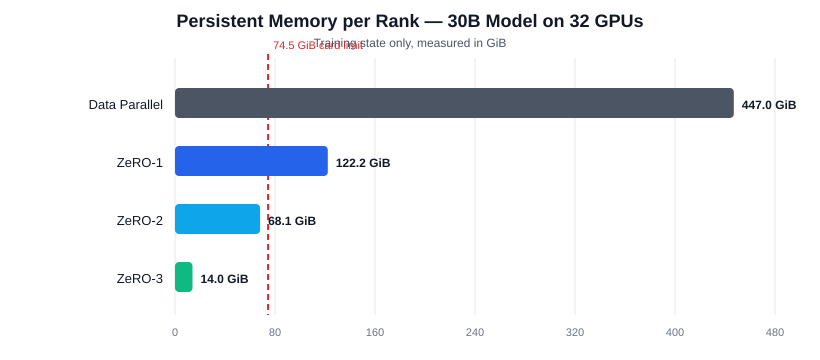

In [9]:
# MEMORY_BAR_CHART
memory_chart_labels = STRATEGIES
memory_chart_values = [gib(MODEL_30B, bytes_per_parameter(strategy, 32)) for strategy in STRATEGIES]


def build_memory_bar_svg(labels, values, card_limit=74.5):
    width, height = 820, 360
    left, right, top = 175, 775, 58
    chart_width = right - left
    maximum = 480.0
    colors = ["#4B5563", "#2563EB", "#0EA5E9", "#10B981"]
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<text x="410" y="27" text-anchor="middle" font-family="Arial" font-size="18" font-weight="bold" fill="#111827">Persistent Memory per Rank — 30B Model on 32 GPUs</text>',
        '<text x="410" y="47" text-anchor="middle" font-family="Arial" font-size="12" fill="#4B5563">Training state only, measured in GiB</text>',
    ]
    for tick in range(0, 481, 80):
        x = left + chart_width * tick / maximum
        parts.append(f'<line x1="{x:.1f}" y1="{top}" x2="{x:.1f}" y2="{height - 45}" stroke="#E5E7EB" stroke-width="1"/>')
        parts.append(f'<text x="{x:.1f}" y="{height - 24}" text-anchor="middle" font-family="Arial" font-size="11" fill="#6B7280">{tick}</text>')
    limit_x = left + chart_width * card_limit / maximum
    parts.append(f'<line x1="{limit_x:.1f}" y1="{top - 4}" x2="{limit_x:.1f}" y2="{height - 45}" stroke="#DC2626" stroke-width="2" stroke-dasharray="6,4"/>')
    parts.append(f'<text x="{limit_x + 5:.1f}" y="{top - 9}" font-family="Arial" font-size="11" fill="#DC2626">74.5 GiB card limit</text>')
    for index, (label, value) in enumerate(zip(labels, values)):
        y = top + 30 + index * 58
        bar_width = chart_width * value / maximum
        parts.append(f'<text x="{left - 12}" y="{y + 21}" text-anchor="end" font-family="Arial" font-size="13" fill="#111827">{label}</text>')
        parts.append(f'<rect x="{left}" y="{y}" width="{bar_width:.1f}" height="30" rx="4" fill="{colors[index]}"/>')
        parts.append(f'<text x="{min(left + bar_width + 8, right - 3):.1f}" y="{y + 21}" font-family="Arial" font-size="12" font-weight="bold" fill="#111827">{value:.1f} GiB</text>')
    parts.append('</svg>')
    return ''.join(parts)


MEMORY_CHART_SVG = build_memory_bar_svg(memory_chart_labels, memory_chart_values)
try:
    from IPython.display import SVG, display
    display(SVG(MEMORY_CHART_SVG))
except ImportError:
    print("Graphical SVG display is available in Jupyter and Colab. Text fallback:")
    scale = 48 / max(memory_chart_values)
    for label, value in zip(memory_chart_labels, memory_chart_values):
        print(f"{label:<15} {'#' * max(1, round(value * scale))} {value:.1f} GiB")

## 8. Computation and communication changes

Forward/backward model arithmetic per rank stays approximately the same because every rank still processes its microbatch. The optimizer work changes sharply: data parallelism updates all `P` parameters on every rank, whereas each ZeRO rank updates `P/N`.

ZeRO-3 does not reduce the core model FLOPs in this example. Its extra work is orchestration and parameter materialization, and its extra cost is communication.

In [10]:
ring_factor = (WORLD_SIZE - 1) / WORLD_SIZE
model_work = 3 * SAMPLES_PER_RANK * PARAM_COUNT

print(f"{'Strategy':<15} {'Model work/rank':>17} {'Optimizer/rank':>16} {'Optimizer global':>18} {'Collectives per step':>28}")
print('-' * 101)
for strategy in STRATEGIES:
    optimizer_per_rank = PARAM_COUNT if strategy == "Data Parallel" else SHARD_SIZE
    optimizer_global = optimizer_per_rank * WORLD_SIZE
    if strategy == "Data Parallel":
        collectives = "gradient all-reduce"
    elif strategy in ("ZeRO-1", "ZeRO-2"):
        collectives = "reduce-scatter + all-gather"
    else:
        collectives = "2 param gathers + reduce-scatter"
    print(
        f"{strategy:<15} {model_work:>17,} {optimizer_per_rank:>16,} "
        f"{optimizer_global:>18,} {collectives:>28}"
    )

print()
print(f"Exact 32-rank DP/ZeRO-1/ZeRO-2 communication: {2 * ring_factor:.4f}P per step (about 2P)")
print(f"Exact 32-rank ZeRO-3 communication:            {3 * ring_factor:.4f}P per step (about 3P)")
print(f"For the 30B example, P = 60 GB, so the lesson approximation is 120 GB versus 180 GB per rank per step.")

Strategy          Model work/rank   Optimizer/rank   Optimizer global         Collectives per step
-----------------------------------------------------------------------------------------------------
Data Parallel              24,576            1,024             32,768          gradient all-reduce
ZeRO-1                     24,576               32              1,024  reduce-scatter + all-gather
ZeRO-2                     24,576               32              1,024  reduce-scatter + all-gather
ZeRO-3                     24,576               32              1,024 2 param gathers + reduce-scatter

Exact 32-rank DP/ZeRO-1/ZeRO-2 communication: 1.9375P per step (about 2P)
Exact 32-rank ZeRO-3 communication:            2.9062P per step (about 3P)
For the 30B example, P = 60 GB, so the lesson approximation is 120 GB versus 180 GB per rank per step.


## 9. What I understood from the experiment

My main takeaway is that ZeRO is a sequence of ownership changes, not a different learning algorithm. Every stage used the same batches and produced equivalent FP32 master parameters and Adam moments after four updates.

The first large saving comes from ZeRO-1 because the master parameters and two Adam moments account for 12 of the 16 bytes stored per parameter. ZeRO-2 then removes persistent copies of non-owned gradients. ZeRO-3 also removes persistent copies of non-owned parameters, but those parameters must be gathered when computation reaches them.

The result that stood out to me is that ZeRO-1 and ZeRO-2 can reduce memory without increasing the lesson's approximate `2P` communication volume. They reuse the reduce-scatter and all-gather phases that already form an all-reduce. ZeRO-3 crosses to roughly `3P` because parameters are gathered for forward and backward computation.

For the 30B example on 80 GB cards, I would not choose data parallelism or ZeRO-1 because persistent state alone exceeds the card. ZeRO-2 first fits at 32 GPUs in the table, while ZeRO-3 fits from 8. My choice between them would depend on measured activation memory and network time: I would prefer ZeRO-2 when 32 GPUs and headroom are available, and use ZeRO-3 when memory capacity is the binding constraint.

The CPU timing is not evidence that one stage is faster on GPUs. A production decision must measure the real architecture, largest gathered layer, activations, temporary buffers, topology, bucket sizes, and overlap efficiency.

### My submission check

I can explain the memory formulas, why the updates remain equivalent, why ZeRO-3 communicates more, and which stage I would select under a specific memory/network constraint.